<h3 style="color:darkorange">1. Initialization</h3>

#### Import necessary libraries and set environment variables.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm  import tqdm
import tifffile
from unetext3Dn_con7 import UNet3D
import cellectP

<h3 style="color:darkorange">2. Load example images</h3>

#### Load and visualize sample TIFF images from specified paths.

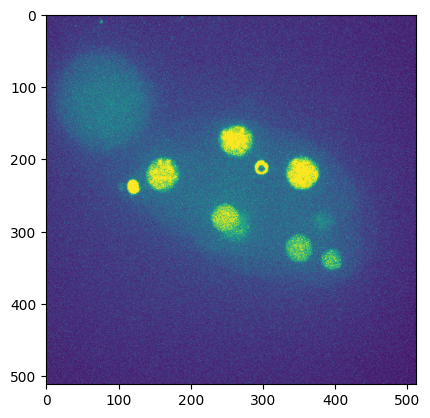

In [6]:
"""
Note: While polar bodies were annotated as a distinct class, they were intentionally excluded from model.
"""
path='./extradata/mskcc-confocal/mskcc_confocal_s1/images/'
img=tifffile.TiffFile(path+'mskcc_confocal_s1_t020.tif').asarray().transpose([1,2,0])#[120:120+256,120:120+256]
img2=tifffile.TiffFile(path+'mskcc_confocal_s1_t021.tif').asarray().transpose([1,2,0])#[120:120+256,120:120+256]
img3=tifffile.TiffFile(path+'mskcc_confocal_s1_t022.tif').asarray().transpose([1,2,0])#[120:120+256,120:120+256]
plt.imshow(img3.max(-1),vmax=3000)


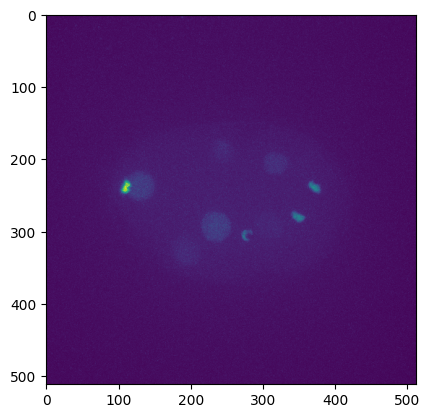

In [3]:
plt.imshow(img3.max(-1))

<h3 style="color:darkorange">3. Load pre-trained models images</h3>

#### Set CUDA device, initialize UNet3D and EXNet models, set to eval and load pretrained weights.

In [4]:

os.environ['CUDA_VISIBLE_DEVICES']='0'
device = torch.device("cuda:0") if torch.cuda.is_available() else 'cpu'
U =UNet3D(2,6)
EX=cellectP.EXNet(64,8)
EN=cellectP.EXNet(64,6)
U.to(device)
EX.to(device)
EN.to(device)
U.eval()
EX.eval()
EN.eval()
if device == 'cpu':
    U.load_state_dict(torch.load('./model/U-ext+-x3rd-149.0-4.6540.pth',map_location=torch.device('cpu')))
    EX.load_state_dict(torch.load('./model/EX+-x3rd-149.0-4.6540.pth',map_location=torch.device('cpu')))
    EN.load_state_dict(torch.load('./model/EN+-x3rd-149.0-4.6540.pth',map_location=torch.device('cpu'))) 
else:
    U.load_state_dict(torch.load('./model/U-ext+-x3rd-149.0-4.6540.pth'))
    EX.load_state_dict(torch.load('./model/EX+-x3rd-149.0-4.6540.pth'))
    EN.load_state_dict(torch.load('./model/EN+-x3rd-149.0-4.6540.pth'))


<h3 style="color:darkorange">4. Setup preprocessing</h3>

Preprocess function PA shifts intensities based on data range [2000–65536].  
- Subtracts min, adds 1900 so minimum maps to 1900.  
- Applies log1p for compression.  
These adjustments can better match your training data, though the default (without shift) also often works well.

In [5]:
def PA(x):
    x=x.float()
    af=x[x>0].min()
    x[x<af]=af
    x=x+1900
    x=torch.log1p(x)
    return x

Convert numpy images to torch tensors and check shape

In [6]:
img=torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device).float()
img2=torch.from_numpy(img2).unsqueeze(0).unsqueeze(0).to(device).float()
img3=torch.from_numpy(img3).unsqueeze(0).unsqueeze(0).to(device).float()
img.shape

torch.Size([1, 1, 512, 512, 41])

<h3 style="color:darkorange">5. Tracking</h3>

Run CELLECT tracking with frames, z-ratio, preprocessing, and models.
Inputs:
 - img, img2, img3: three consecutive frames
 - 5: z/xy resolution ratio
 - PA: preprocessing function
 - U, EX, EN: three trained models
 - div: enable divison
Outputs:
 - result: dict with keys for frame1/2 feature vectors and positions, inter-frame link results, and model scores.

In [7]:
import cellectP
result=cellectP.track(img, img2, img3, 5, PA, U, EX, EN, div=1 )
result1=cellectP.track(img, img, img, 5, PA, U, EX, EN, div=1 )
result.keys()
result1.keys()

/home/chenzunhao/CELLECT/cellectP.py:407: UserWarning: This overload of addmm_ is deprecated:
	addmm_(Number beta, Number alpha, Tensor mat1, Tensor mat2)
Consider using one of the following signatures instead:
	addmm_(Tensor mat1, Tensor mat2, *, Number beta = 1, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1853.)
  distmat.addmm_(1, -2, px1.float(),px1.float().t())
/home/chenzunhao/CELLECT/cellectP.py:593: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  c=F.softmax(sp)


dict_keys(['frame1', 'frame2', 'inter-score', 'link'])

<h3 style="color:darkorange">6. Visualization</h3>

In [8]:
result['frame1'].keys()

dict_keys(['intra-score', 'pos', 'feature', 'size', 'div', 'seg', 'seg_mask', 'group'])

In [9]:
result['frame1']['pos']

tensor([[234., 131.,  95.],
        [238., 111., 170.],
        [199., 258., 130.],
        [204., 307., 105.],
        [252., 359., 100.],
        [300., 249.,  55.],
        [315., 187., 140.],
        [259., 420., 100.],
        [315., 314., 140.],
        [336., 291., 155.],
        [267., 418., 125.]], device='cuda:0')

In [10]:
print(result['frame1']['feature'].shape)
print(result1['frame2']['size'])
print(result['frame1']['div'].shape)
print(result['frame1']['seg'].shape)

torch.Size([11, 64])
tensor([ 2.5470, 20.3245, 15.5901, 10.9012, 17.4223, 13.9019, 19.7610,  3.6923,
        13.9271, 10.3367,  3.2250,  4.4859], device='cuda:0')
torch.Size([11, 2])
torch.Size([512, 512, 41])


Plot frame1 detected positions on img max-projection.

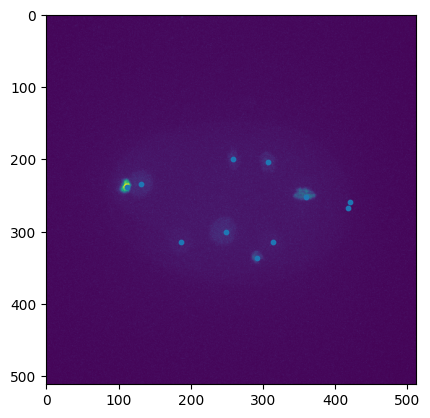

In [11]:
p1=result['frame1']['pos'].cpu()
plt.imshow(img.squeeze().cpu().max(-1)[0])
plt.scatter(p1[:,1],p1[:,0],s=10)

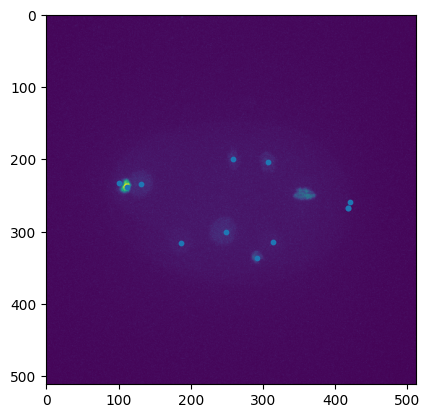

In [12]:
p11=result1['frame1']['pos'].cpu()
plt.imshow(img.squeeze().cpu().max(-1)[0])
plt.scatter(p11[:,1],p11[:,0],s=10)

Plot frame2 detected positions on img2 max-projection.

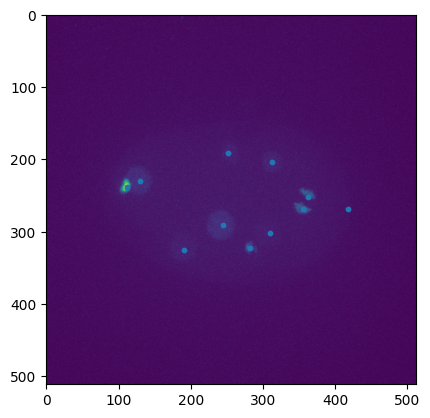

In [13]:
p1=result['frame2']['pos'].cpu()
plt.imshow(img2.squeeze().cpu().max(-1)[0])
plt.scatter(p1[:,1],p1[:,0],s=10)

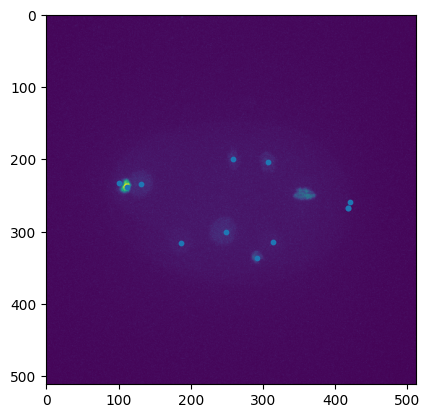

In [14]:
p11=result1['frame2']['pos'].cpu()
plt.imshow(img.squeeze().cpu().max(-1)[0])
plt.scatter(p11[:,1],p11[:,0],s=10)

In [15]:
result['link']

{0: [0],
 1: [1],
 2: [2],
 3: [3],
 4: [4, 7],
 5: [5],
 6: [6],
 7: [],
 8: [8],
 9: [9],
 10: [10]}

Overlay frame1 (red) and frame2 (blue) detections on img max-projection.

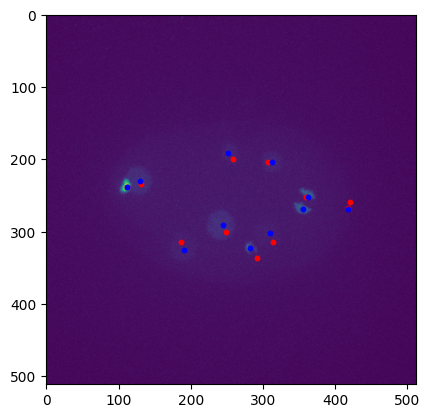

In [16]:
r=result['link']
frame1_linked=np.array(list(r.keys()))
frame2_linked=np.unique([item for sublist in r.values() for item in sublist])
p1=result['frame1']['pos'].cpu()
p2=result['frame2']['pos'].cpu()
plt.imshow(img2.squeeze().cpu().max(-1)[0])
plt.scatter(p1[frame1_linked,1],p1[frame1_linked,0],c='red',s=10)
plt.scatter(p2[frame2_linked,1],p2[frame2_linked,0],c='b', s=10)

Annotate tracking links with arrows from frame1 to frame2.

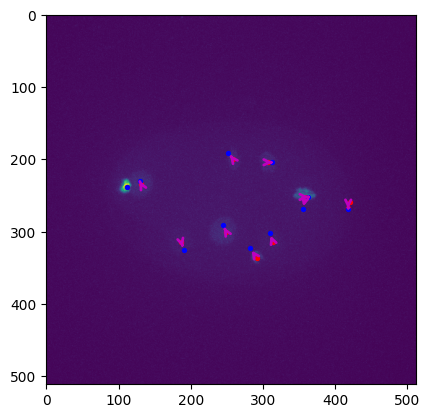

In [17]:
p1=result['frame1']['pos'].cpu()
p2=result['frame2']['pos'].cpu()
plt.imshow(img.squeeze().cpu().max(-1)[0])
plt.scatter(p1[frame1_linked,1],p1[frame1_linked,0],c='red',s=8)
plt.scatter(p2[frame2_linked,1],p2[frame2_linked,0],c='b',s=8)
for i in r:
    for j in r[i]:
        plt.annotate('', xy=(p2[j,1], p2[j,0]), xytext=(p1[i,1], p1[i,0]),
                     arrowprops=dict(arrowstyle='->', color='m', lw=2))


Display variable 'r' containing link results.

In [18]:
r

{0: [0],
 1: [1],
 2: [2],
 3: [3],
 4: [4, 7],
 5: [5],
 6: [6],
 7: [],
 8: [8],
 9: [9],
 10: [10]}

Visualize a simple instance segmentation result based on
coarse segmentation confidence map and size prediction.

This plots the max-projection over z of the predicted confidence-based
instance mask for a given frame.

In [19]:
print(result['frame1']['seg'].cpu().numpy().max((0,1)))
print(result['frame1']['seg_mask'].max((0,1)))

[0. 1. 0. 0. 0. 0. 2. 4. 4. 8. 8. 8. 8. 8. 8. 8. 6. 8. 8. 8. 8. 8. 8. 8.
 8. 8. 8. 8. 8. 8. 8. 8. 4. 4. 4. 4. 4. 4. 4. 3. 2.]
[ 0.  0.  0.  0.  0.  0.  0.  6.  6.  6.  6.  6.  6.  6.  6.  6.  5.  5.
  5.  8.  8.  8.  5.  5. 11. 11. 11.  9. 10. 10. 10. 10. 10. 10.  2.  2.
  2.  2.  2.  0.  0.]


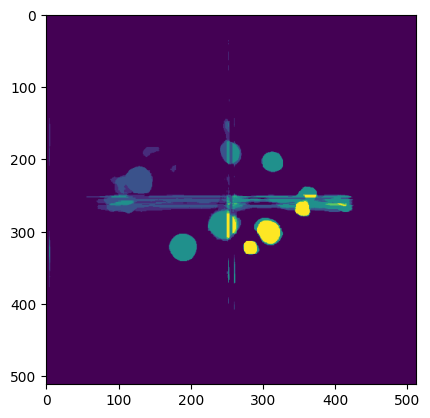

In [20]:
plt.imshow(result['frame2']['seg'].cpu().numpy().max(-1))

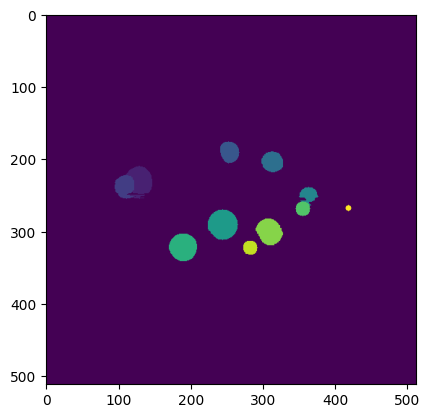

In [21]:
plt.imshow(result['frame2']['seg_mask'].max(-1))

Plot the binary segmentation mask (mask > 0) for a single frame.

Statistics
Total unique cell IDs in segmentation mask: 12
Mask max value: [ 0.  0.  0.  0.  0.  0.  0.  6.  6.  6.  6.  6.  6.  6.  6.  6.  5.  5.
  5.  8.  8.  8.  5.  5. 11. 11. 11.  9. 10. 10. 10. 10. 10. 10.  2.  2.
  2.  2.  2.  0.  0.]
Processing cell ID: 0.0
Single mask for cell ID 0.0: 10699362 pixels
Processing cell ID: 1.0
Single mask for cell ID 1.0: 10440 pixels
Processing cell ID: 2.0
Single mask for cell ID 2.0: 3507 pixels
Processing cell ID: 3.0
Single mask for cell ID 3.0: 3398 pixels
Processing cell ID: 4.0
Single mask for cell ID 4.0: 3645 pixels
Processing cell ID: 5.0
Single mask for cell ID 5.0: 5719 pixels
Processing cell ID: 6.0
Single mask for cell ID 6.0: 6720 pixels
Processing cell ID: 7.0
Single mask for cell ID 7.0: 7850 pixels
Processing cell ID: 8.0
Single mask for cell ID 8.0: 140 pixels
Processing cell ID: 9.0
Single mask for cell ID 9.0: 5225 pixels
Processing cell ID: 10.0
Single mask for cell ID 10.0: 1811 pixels
Processing cell ID: 11.0
Single mask 

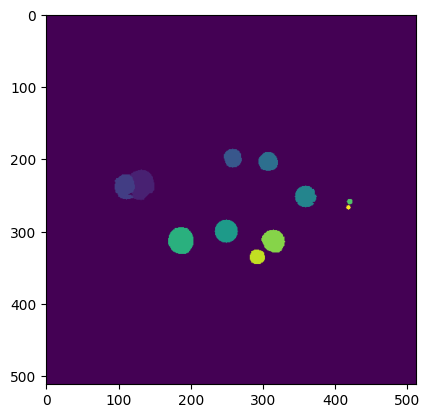

In [22]:
plt.imshow(result['frame1']['seg_mask'].max(-1))
seg_mask=result['frame1']['seg_mask']
cell_ids=np.unique(seg_mask)
print('Statistics')
print(f'Total unique cell IDs in segmentation mask: {len(cell_ids)}')
print(f'Mask max value: {np.max(seg_mask, axis=(0,1))}')
single_masks = {}
for cid in cell_ids:
    print(f'Processing cell ID: {cid}')
    single_masks[int(cid)] = (seg_mask == cid)
    print(f'Single mask for cell ID {cid}: {single_masks[int(cid)].sum()} pixels')

Statistics
Total unique cell IDs in segmentation mask: 13
Mask max value: [ 0.  0.  0.  0.  0.  0.  0.  6.  6.  6.  6.  6.  6.  6.  6.  6.  2.  5.
 12. 12. 12. 12. 12.  5. 11. 11. 11.  9. 10. 10. 10. 10. 10. 10.  3.  3.
  3.  3.  3.  0.  0.]
Processing cell ID: 0.0
Single mask for cell ID 0.0: 10704821 pixels
Processing cell ID: 1.0
Single mask for cell ID 1.0: 66 pixels
Processing cell ID: 2.0
Single mask for cell ID 2.0: 10508 pixels
Processing cell ID: 3.0
Single mask for cell ID 3.0: 3526 pixels
Processing cell ID: 4.0
Single mask for cell ID 4.0: 3302 pixels
Processing cell ID: 5.0
Single mask for cell ID 5.0: 3636 pixels
Processing cell ID: 6.0
Single mask for cell ID 6.0: 6731 pixels
Processing cell ID: 7.0
Single mask for cell ID 7.0: 7901 pixels
Processing cell ID: 8.0
Single mask for cell ID 8.0: 135 pixels
Processing cell ID: 9.0
Single mask for cell ID 9.0: 5046 pixels
Processing cell ID: 10.0
Single mask for cell ID 10.0: 1758 pixels
Processing cell ID: 11.0
Single mask fo

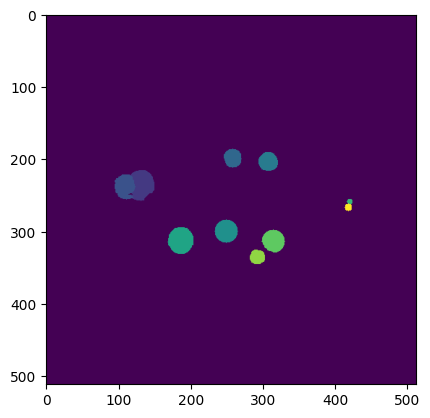

In [23]:
plt.imshow(result1['frame1']['seg_mask'].max(-1))
seg_mask=result1['frame1']['seg_mask']
cell_ids=np.unique(seg_mask)
print('Statistics')
print(f'Total unique cell IDs in segmentation mask: {len(cell_ids)}')
print(f'Mask max value: {np.max(seg_mask, axis=(0,1))}')
single_masks = {}
for cid in cell_ids:
    print(f'Processing cell ID: {cid}')
    single_masks[int(cid)] = (seg_mask == cid)
    print(f'Single mask for cell ID {cid}: {single_masks[int(cid)].sum()} pixels')

In [24]:
[item for sublist in r.values() for item in sublist]

[0, 1, 2, 3, 4, 7, 5, 6, 8, 9, 10]